In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List, Dict
from langchain_google_genai.chat_models import ChatGoogleGenerativeAI
from langchain.messages import HumanMessage
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
model = ChatGoogleGenerativeAI(model='gemini-2.5-flash', temperature=1)
model.invoke("What is the capital of France?")

AIMessage(content='The capital of France is **Paris**.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d48c8-b9aa-7cb3-b5c5-364881264e70-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 35, 'total_tokens': 43, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 27}})

In [3]:
class BlogState(TypedDict):
    topic: str
    outline: str
    blog:str
    rating:int

In [4]:
def create_outline(state:BlogState)-> BlogState:
    topic = state['topic']
    prompt = f"Create a detailed outline for a blog post about {topic}"
    outline = model.invoke(prompt).content
    state['outline'] = outline
    return state

In [5]:
def create_blog(state:BlogState) -> BlogState:
    topic = state['topic']
    outline = state['outline']
    prompt = f"Create a detailed blog post on topic :{topic}\nwith following outline:\n{outline}"
    blog = model.invoke(prompt).content
    state['blog'] = blog
    return state

In [6]:
def rate_blog(state:BlogState) -> BlogState:
    blog = state['blog']
    prompt = f"Rate the following blog on a scale of 1 to 10 and provide feedback for improvement:\n{blog}"
    rating = model.invoke(prompt).content
    state['rating'] = rating
    return state

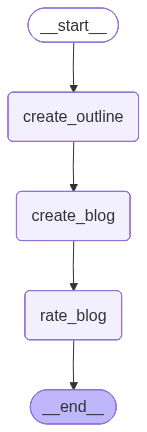

In [7]:
graph = StateGraph(BlogState)

graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)
graph.add_node("rate_blog", rate_blog)
graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", "rate_blog")
graph.add_edge("rate_blog", END)

workflow = graph.compile()
workflow

In [8]:
final_res = workflow.invoke({"topic":"Artificial Intelligence"})

In [9]:
print(final_res['blog'])

## Demystifying AI: Your Essential Guide to Artificial Intelligence

Ever asked Siri for directions, had Netflix recommend your next binge-watch, or marveled at how a Google search instantly understands your query? If so, you've already interacted with Artificial Intelligence. AI isn't just a sci-fi dream confined to futuristic films; it's interwoven into the fabric of our daily lives, subtly enhancing experiences and quietly powering the digital world around us.

The term "AI" itself is everywhere – in news headlines, social media debates, and often, in our anxieties about the future. This widespread discussion, however, frequently comes with a mix of excitement, fear, and, often, significant misunderstanding. From fears of sentient robots to promises of utopian futures, the conversation around AI can be confusing.

This post aims to demystify Artificial Intelligence, breaking down its core concepts, real-world applications, immense potential, and crucial challenges, so you can naviga

In [10]:
print(final_res['rating'])


## Rating: 9/10

This is an **excellent, comprehensive, and well-structured blog post** that genuinely delivers on its promise to demystify AI. It's informative, accessible, and balanced, providing a solid foundation for anyone looking to understand Artificial Intelligence.

---

### Strengths:

1.  **Clear & Engaging Introduction:** The hook is fantastic, using relatable everyday examples to immediately show readers they already interact with AI. It clearly sets the stage and defines the post's objective.
2.  **Logical Structure & Flow:** The post follows a very intuitive progression, starting with "What" (definitions, history, types), moving to "How" (building blocks), then "Where" (applications), "Why" (potential), "What are the problems" (challenges), and finally "What's next" (future). The headings and subheadings are clear and helpful for navigation.
3.  **Accessible Language & Analogies:** Complex concepts like Machine Learning and Deep Learning are explained simply, often with 